In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv('spambase.csv')

# Handle missing or infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

# Convert all data to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Separate features and target variable
X = df.drop(columns=['spam']).to_numpy()  # Convert to numpy array
y = df['spam'].to_numpy()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


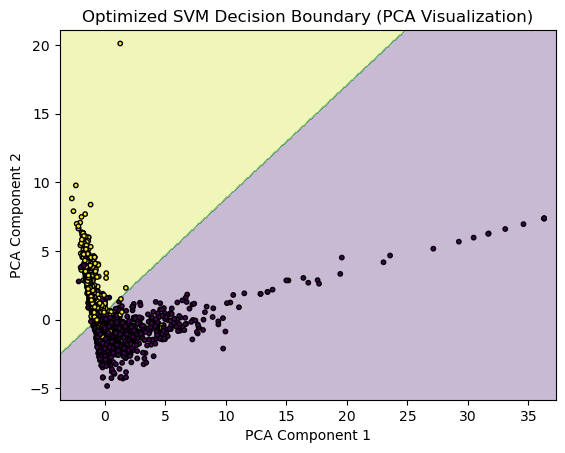

In [3]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Train SVM on reduced data for visualization only
svm_visual = SVC(kernel='linear', C=1.0, random_state=42)
svm_visual.fit(X_train_pca, y_train)

# Generate mesh grid
h = 0.1  # Step size for faster computation
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict decision boundary
Z = svm_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', s=10)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Optimized SVM Decision Boundary (PCA Visualization)')
plt.show()

SVM Accuracy: 0.93
SVM Classification Report:
               precision    recall  f1-score   support

    not spam       0.92      0.97      0.94       531
        spam       0.95      0.89      0.92       390

    accuracy                           0.93       921
   macro avg       0.94      0.93      0.93       921
weighted avg       0.94      0.93      0.93       921



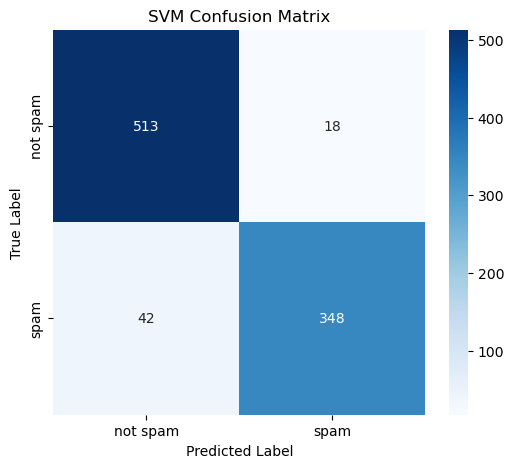

Decision Tree Accuracy: 0.92
Decision Tree Classification Report:
               precision    recall  f1-score   support

    not spam       0.92      0.94      0.93       531
        spam       0.92      0.89      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.92      0.92      0.92       921



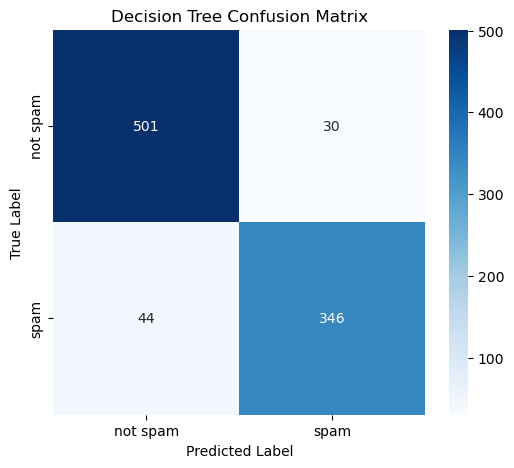

Naive Bayes Accuracy: 0.82
Naive Bayes Classification Report:
               precision    recall  f1-score   support

    not spam       0.94      0.74      0.83       531
        spam       0.72      0.94      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921



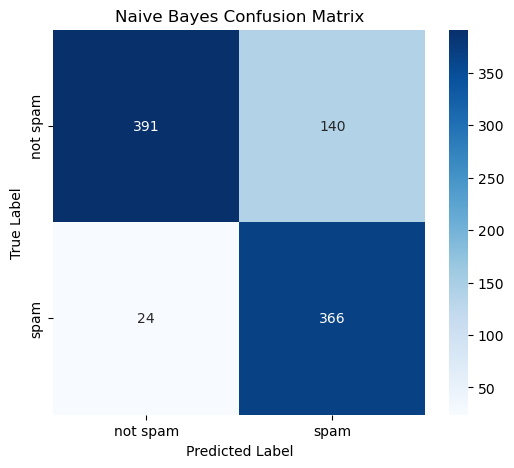

Logistic Regression Accuracy: 0.92
Logistic Regression Classification Report:
               precision    recall  f1-score   support

    not spam       0.91      0.95      0.93       531
        spam       0.93      0.87      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



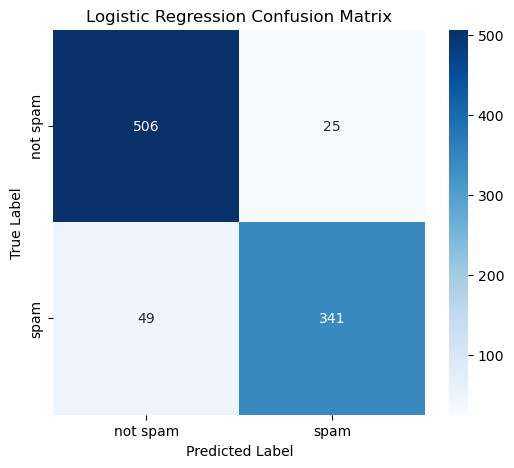

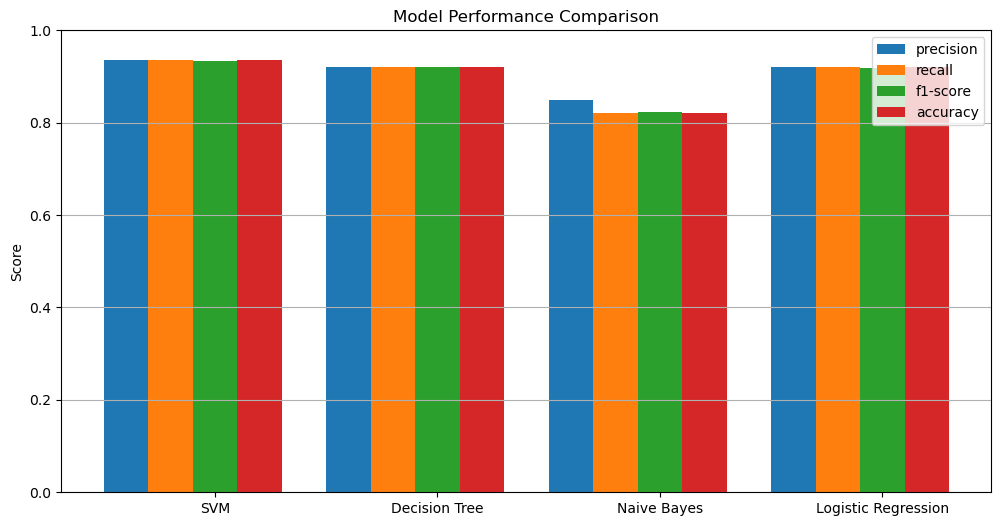

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Train models **without PCA** (to retain full information)
models = {
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Map labels 0 and 1 to 'not spam' and 'spam'
label_map = {0: 'not spam', 1: 'spam'}

results = {}
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Map predictions and actual labels to 'spam'/'not spam'
    y_pred_label = [label_map[label] for label in y_pred]
    y_test_label = [label_map[label] for label in y_test]
    
    results[name] = classification_report(y_test_label, y_pred_label, output_dict=True)
    accuracy_results[name] = accuracy_score(y_test_label, y_pred_label)
    
    print(f'{name} Accuracy: {accuracy_results[name]:.2f}')
    print(f'{name} Classification Report:\n', classification_report(y_test_label, y_pred_label))
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test_label, y_pred_label, labels=['not spam', 'spam'])
    
    # Plot confusion matrix as a heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['not spam', 'spam'], yticklabels=['not spam', 'spam'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Compare model performance
metrics = ['precision', 'recall', 'f1-score', 'accuracy']
metric_results = {
    metric: {model: results[model]['weighted avg'][metric] if metric != 'accuracy' else accuracy_results[model] for model in results}
    for metric in metrics
}

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.2  # Width of bars
x = np.arange(len(results))

for i, metric in enumerate(metrics):
    values = [metric_results[metric][model] for model in results]
    ax.bar(x + i * width, values, width, label=metric)

ax.set_xticks(x + width * (len(metrics) / 2))
ax.set_xticklabels(results.keys())
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y')
plt.show()


SVM Accuracy: 0.93
SVM Classification Report:
               precision    recall  f1-score   support

    not spam       0.92      0.97      0.94       531
        spam       0.95      0.89      0.92       390

    accuracy                           0.93       921
   macro avg       0.94      0.93      0.93       921
weighted avg       0.94      0.93      0.93       921

Decision Tree Accuracy: 0.92
Decision Tree Classification Report:
               precision    recall  f1-score   support

    not spam       0.92      0.94      0.93       531
        spam       0.92      0.89      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.92      0.92      0.92       921

Naive Bayes Accuracy: 0.82
Naive Bayes Classification Report:
               precision    recall  f1-score   support

    not spam       0.94      0.74      0.83       531
        spam       0.72      0.94      0.82       390

    a

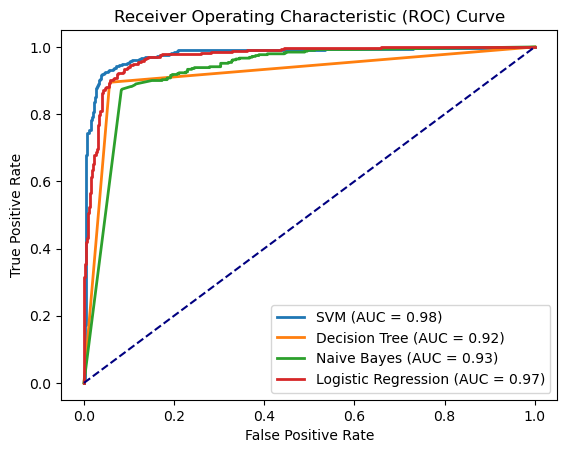


Model Performance Comparison:
                 Model  Precision    Recall  F1-Score  Accuracy
0                  SVM   0.935544  0.934853  0.934539  0.934853
1        Decision Tree   0.919667  0.919653  0.919441  0.919653
2          Naive Bayes   0.849497  0.821933  0.822542  0.821933
3  Logistic Regression   0.920173  0.919653  0.919265  0.919653


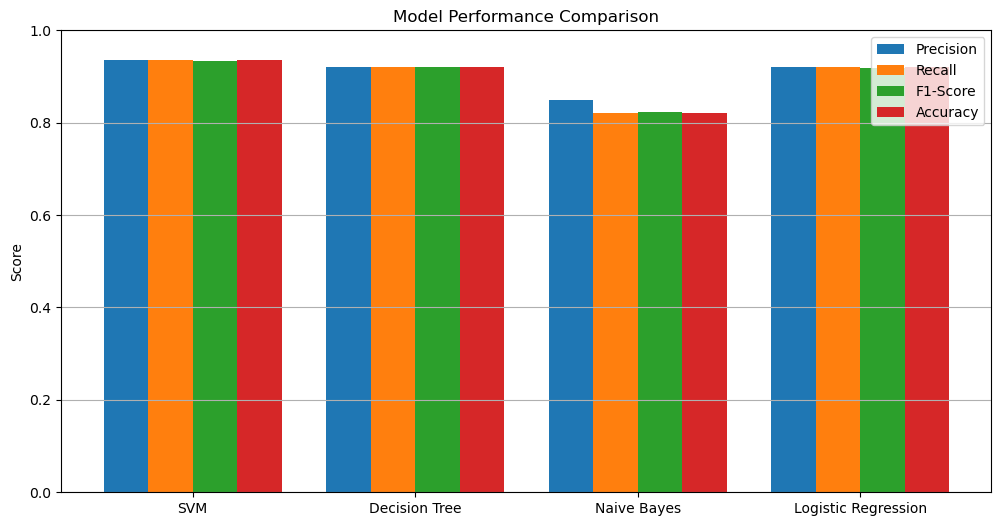

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Train models **without PCA** (to retain full information)
models = {
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True),  # Enable probability for ROC curve
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Map labels 0 and 1 to 'not spam' and 'spam'
label_map = {0: 'not spam', 1: 'spam'}

results = {}
accuracy_results = {}

# Store metrics for each model
metrics_summary = []

# Binarizer for labels (necessary for plotting ROC curve)
lb = LabelBinarizer()

# Fit models, calculate metrics, and plot ROC curves
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Map predictions and actual labels to 'spam'/'not spam'
    y_pred_label = [label_map[label] for label in y_pred]
    y_test_label = [label_map[label] for label in y_test]
    
    # Generate classification report
    class_report = classification_report(y_test_label, y_pred_label, output_dict=True)
    
    # Accuracy
    accuracy = accuracy_score(y_test_label, y_pred_label)
    
    # Precision, Recall, F1-Score for weighted avg
    precision = class_report['weighted avg']['precision']
    recall = class_report['weighted avg']['recall']
    f1_score = class_report['weighted avg']['f1-score']
    
    # Store model metrics
    metrics_summary.append([name, precision, recall, f1_score, accuracy])

    # Print classification report and accuracy
    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Classification Report:\n', classification_report(y_test_label, y_pred_label))
    
    # Compute ROC curve and AUC
    y_test_bin = lb.fit_transform(y_test)  # Binarize true labels
    y_prob = model.predict_proba(X_test)[:, 1]  # Get probability estimates for the positive class
    
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot ROC curve for all models
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line (random classifier)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Convert metrics summary to a DataFrame
metrics_df = pd.DataFrame(metrics_summary, columns=['Model', 'Precision', 'Recall', 'F1-Score', 'Accuracy'])

# Display the comparison table
print("\nModel Performance Comparison:")
print(metrics_df)

# Plotting each metric comparison across models
fig, ax = plt.subplots(figsize=(12, 6))

# Set width for the bars and X-axis positions
width = 0.2
x = range(len(models))

# Create bars for each metric (precision, recall, f1-score, accuracy)
for i, metric in enumerate(['Precision', 'Recall', 'F1-Score', 'Accuracy']):
    values = metrics_df[metric].values
    ax.bar([p + i * width for p in x], values, width, label=metric)

# Set labels for the X-axis and title
ax.set_xticks([p + width * 1.5 for p in x])
ax.set_xticklabels(metrics_df['Model'])
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y')
plt.show()


In [1]:
import pickle

# Save trained models
with open("model.pkl", "wb") as f:
    pickle.dump(models, f)

# Save vectorizer (if you use text data)
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(scaler, f)  # Since you scaled the numeric data

print("Models and vectorizer saved successfully!")


NameError: name 'models' is not defined